# step1 _ Data Collection & Preprocessing - ML Part

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
## 2. Load the Dataset

In [3]:
df = pd.read_csv("../data/raw/imdb_raw.csv")

df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross
0,The Shawshank Redemption,Frank Darabont,(1994),142 min,Drama,9.3,82,$28.34M
1,The Godfather,Francis Ford Coppola,(1972),175 min,"Crime, Drama",9.2,100,$134.97M
2,The Dark Knight,Christopher Nolan,(2008),152 min,"Action, Crime, Drama",9.0,84,$534.86M
3,Schindler's List,Steven Spielberg,(1993),195 min,"Biography, Drama, History",9.0,95,$96.90M
4,12 Angry Men,Sidney Lumet,(1957),96 min,"Crime, Drama",9.0,97,$4.36M


## 2. Initial Data Exploration

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 8)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   director      1000 non-null   object 
 2   release_year  1000 non-null   object 
 3   runtime       1000 non-null   object 
 4   genre         1000 non-null   object 
 5   rating        1000 non-null   float64
 6   metascore     1000 non-null   int64  
 7   gross         1000 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ KB


In [6]:
df.isnull().sum()

title           0
director        0
release_year    0
runtime         0
genre           0
rating          0
metascore       0
gross           0
dtype: int64

In [7]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [8]:
df.describe()

,rating,metascore
count,1000.00000,1000.000000
mean,7.96870,66.653000
std,0.27562,30.712829
min,7.60000,0.000000
25%,7.80000,64.750000
50%,7.90000,77.000000
75%,8.10000,86.000000
max,9.30000,100.000000


## 3. Data Type Cleaning


In [9]:
df['release_year'] = df['release_year'].astype(str).str.extract(r'(\d{4})')
df['runtime'] = df['runtime'].astype(str).str.extract(r'(\d+)')

df['gross'] = (
    df['gross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('M', '', regex=False)
)

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['gross'] = pd.to_numeric(df['gross'], errors='coerce')

df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34
1,The Godfather,Francis Ford Coppola,1972,175,"Crime, Drama",9.2,100,134.97
2,The Dark Knight,Christopher Nolan,2008,152,"Action, Crime, Drama",9.0,84,534.86
3,Schindler's List,Steven Spielberg,1993,195,"Biography, Drama, History",9.0,95,96.90
4,12 Angry Men,Sidney Lumet,1957,96,"Crime, Drama",9.0,97,4.36


## 4. Handling Missing Values

In [10]:
df.isnull().sum()

title           0
director        0
release_year    0
runtime         0
genre           0
rating          0
metascore       0
gross           0
dtype: int64

In [11]:
numeric_cols = ['release_year', 'runtime', 'rating', 'metascore', 'gross']
categorical_cols = ['title', 'director', 'genre']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

title           0
director        0
release_year    0
runtime         0
genre           0
rating          0
metascore       0
gross           0
dtype: int64

In [13]:
## 6. Removing Duplicate Records

In [14]:
print("Number of duplicated rows before removing:", df.duplicated().sum())

Number of duplicated rows before removing: 0


In [15]:
df = df.drop_duplicates()

print("Number of duplicated rows after removing:", df.duplicated().sum())

Number of duplicated rows after removing: 0


In [16]:
print("Dataset shape after handling missing values and duplicates:", df.shape)

Dataset shape after handling missing values and duplicates: (1000, 8)


## 5. Outlier Detection and Handling

In [17]:
df[['release_year', 'runtime', 'rating', 'metascore', 'gross']].describe()

,release_year,runtime,rating,metascore,gross
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,1991.619000,124.136000,7.96870,66.653000,57.75870
std,24.146861,28.690253,0.27562,30.712829,109.17303
min,1920.000000,45.000000,7.60000,0.000000,0.00000
25%,1975.000000,103.000000,7.80000,64.750000,0.23000
50%,1999.000000,120.000000,7.90000,77.000000,9.40000
75%,2011.000000,138.000000,8.10000,86.000000,60.16750
max,2023.000000,321.000000,9.30000,100.000000,936.66000


In [18]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"{column}:")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    print("-" * 40)

In [19]:
numeric_columns_for_outliers = ['runtime', 'gross']

for col in numeric_columns_for_outliers:
    if col in df.columns:
        detect_outliers_iqr(df, col)

runtime:
Lower Bound: 50.5
Upper Bound: 190.5
Number of Outliers: 25
----------------------------------------
gross:
Lower Bound: -89.67625000000001
Upper Bound: 150.07375000000002
Number of Outliers: 127
----------------------------------------


## 6. Handling Outliers

In [20]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    
    return data

In [21]:
for col in numeric_columns_for_outliers:
    if col in df.columns:
        df = cap_outliers_iqr(df, col)

df[['release_year', 'runtime', 'rating', 'metascore', 'gross']].describe()

,release_year,runtime,rating,metascore,gross
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,1991.619000,123.59450,7.96870,66.653000,39.919456
std,24.146861,26.80762,0.27562,30.712829,53.609093
min,1920.000000,50.50000,7.60000,0.000000,0.000000
25%,1975.000000,103.00000,7.80000,64.750000,0.230000
50%,1999.000000,120.00000,7.90000,77.000000,9.400000
75%,2011.000000,138.00000,8.10000,86.000000,60.167500
max,2023.000000,190.50000,9.30000,100.000000,150.073750


## 7. Save the Preprocessed Dataset

In [22]:
import os

# Create the processed data folder if it does not exist
os.makedirs("../data/processed", exist_ok=True)

# Save the preprocessed dataset
df.to_csv("../data/processed/movie_preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [23]:
print("Final Dataset Shape:", df.shape)
print("-" * 40)

print("Missing Values:")
print(df.isnull().sum())
print("-" * 40)

print("Duplicated Rows:", df.duplicated().sum())

Final Dataset Shape: (1000, 8)
----------------------------------------
Missing Values:
title           0
director        0
release_year    0
runtime         0
genre           0
rating          0
metascore       0
gross           0
dtype: int64
----------------------------------------
Duplicated Rows: 0


In [24]:
df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross
0,The Shawshank Redemption,Frank Darabont,1994,142.0,Drama,9.3,82,28.34000
1,The Godfather,Francis Ford Coppola,1972,175.0,"Crime, Drama",9.2,100,134.97000
2,The Dark Knight,Christopher Nolan,2008,152.0,"Action, Crime, Drama",9.0,84,150.07375
3,Schindler's List,Steven Spielberg,1993,190.5,"Biography, Drama, History",9.0,95,96.90000
4,12 Angry Men,Sidney Lumet,1957,96.0,"Crime, Drama",9.0,97,4.36000


## Preprocessing Summary

In this preprocessing notebook, we prepared the IMDb movie dataset for the next stages of the project.

The following steps were completed:

1. Loaded the IMDb dataset.
2. Explored the dataset structure.
3. Cleaned numerical columns such as release year, runtime, and gross revenue.
4. Handled missing values.
5. Removed duplicate records.
6. Detected and handled outliers using the IQR method.
7. Saved the final cleaned dataset as `movie_preprocessed.csv`.

The dataset is now ready for exploratory data analysis and machine learning model development.

# step2_ Exploratory Data Analysis & Data Visualization

## 1. Import Required Libraries

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Preprocessed Dataset

In [26]:
df = pd.read_csv("../data/processed/movie_preprocessed.csv")

df.head()

,title,director,release_year,runtime,genre,rating,metascore,gross
0,The Shawshank Redemption,Frank Darabont,1994,142.0,Drama,9.3,82,28.34000
1,The Godfather,Francis Ford Coppola,1972,175.0,"Crime, Drama",9.2,100,134.97000
2,The Dark Knight,Christopher Nolan,2008,152.0,"Action, Crime, Drama",9.0,84,150.07375
3,Schindler's List,Steven Spielberg,1993,190.5,"Biography, Drama, History",9.0,95,96.90000
4,12 Angry Men,Sidney Lumet,1957,96.0,"Crime, Drama",9.0,97,4.36000


In [27]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 8)


In [28]:
df.describe()

,release_year,runtime,rating,metascore,gross
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,1991.619000,123.59450,7.96870,66.653000,39.919456
std,24.146861,26.80762,0.27562,30.712829,53.609093
min,1920.000000,50.50000,7.60000,0.000000,0.000000
25%,1975.000000,103.00000,7.80000,64.750000,0.230000
50%,1999.000000,120.00000,7.90000,77.000000,9.400000
75%,2011.000000,138.00000,8.10000,86.000000,60.167500
max,2023.000000,190.50000,9.30000,100.000000,150.073750


## 3. Rating Distribution

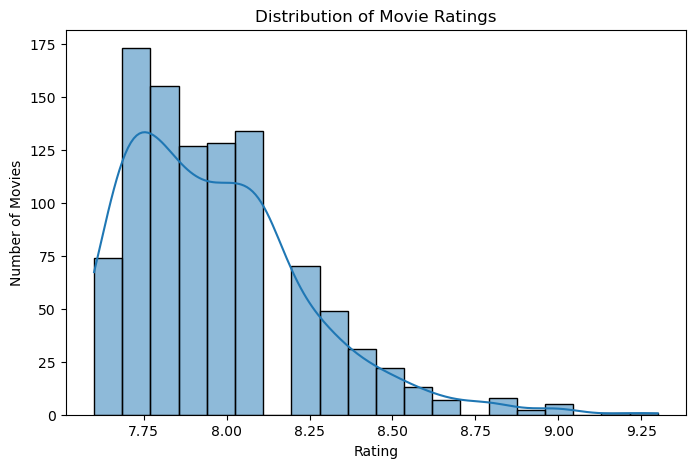

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

## 4. Runtime Distribution

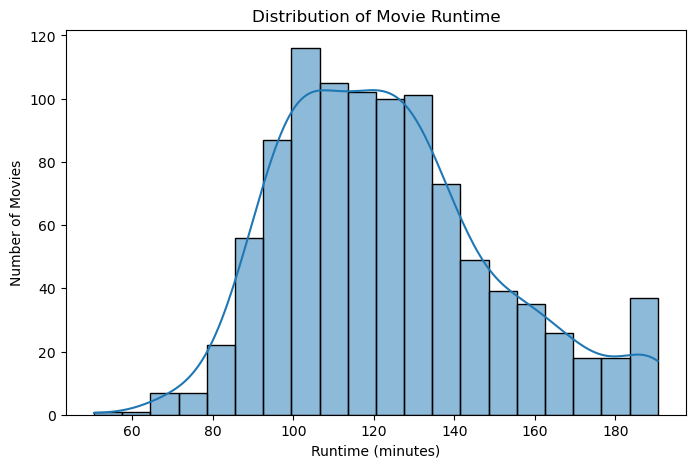

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df['runtime'], bins=20, kde=True)
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.show()

## 5. Top Movie Genres


In [31]:
genre_counts = (
    df['genre']
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

genre_counts.head(10)

genre
Drama        732
Comedy       229
Action       207
Crime        204
Adventure    189
Thriller     141
Romance      126
Biography    107
Mystery      103
Animation     84
Name: count, dtype: int64

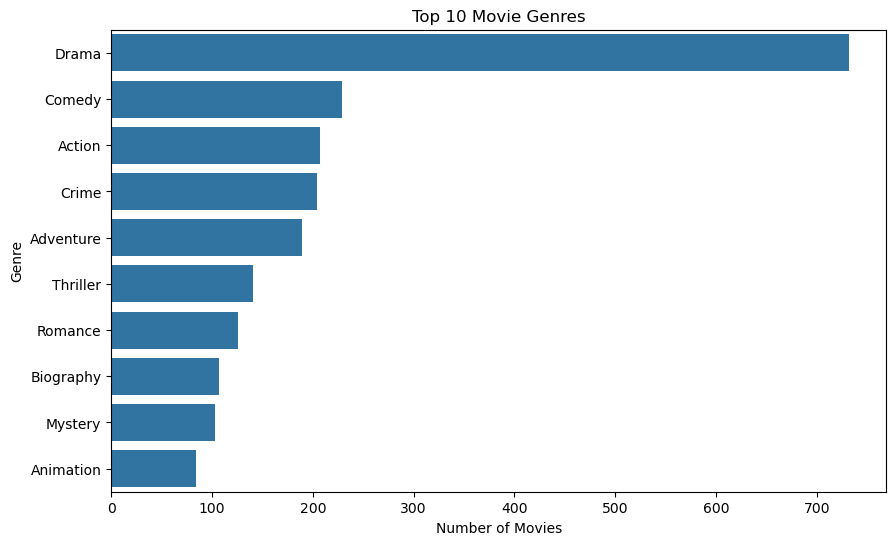

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.head(10).values, y=genre_counts.head(10).index)
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

## 6. Average Rating by Genre

In [33]:
# Create a copy of the dataset for genre analysis
genre_df = df.copy()

# Split multiple genres into separate rows
genre_df['genre'] = genre_df['genre'].astype(str).str.split(',')
genre_df = genre_df.explode('genre')
genre_df['genre'] = genre_df['genre'].str.strip()

  
avg_rating_by_genre = (
    genre_df
    .groupby('genre')['rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_by_genre.head(10)

genre
Western      8.052941
War          8.050000
Crime        7.993137
Mystery      7.991262
Sci-Fi       7.986567
Action       7.986473
Adventure    7.982540
Drama        7.980191
Sport        7.980000
Film-Noir    7.977273
Name: rating, dtype: float64

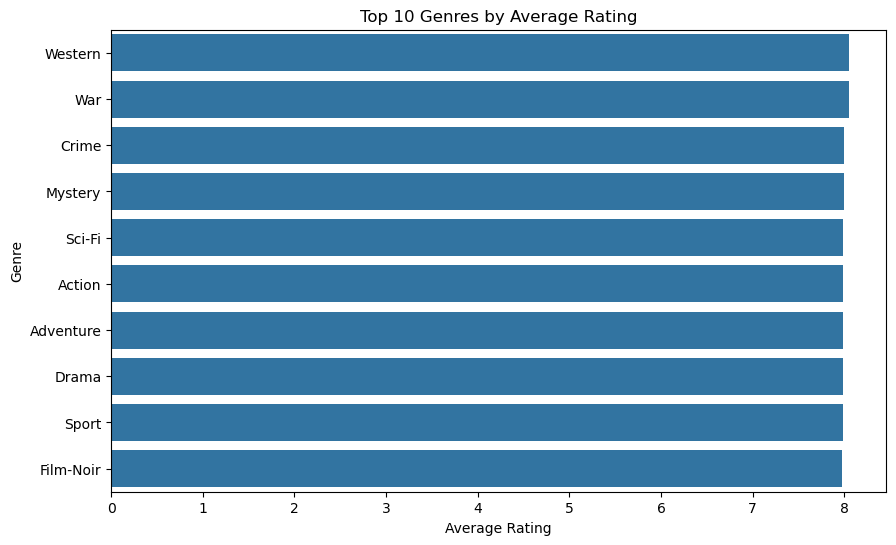

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_by_genre.head(10).values, y=avg_rating_by_genre.head(10).index)
plt.title("Top 10 Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

## 7. Relationship Between Runtime and Rating

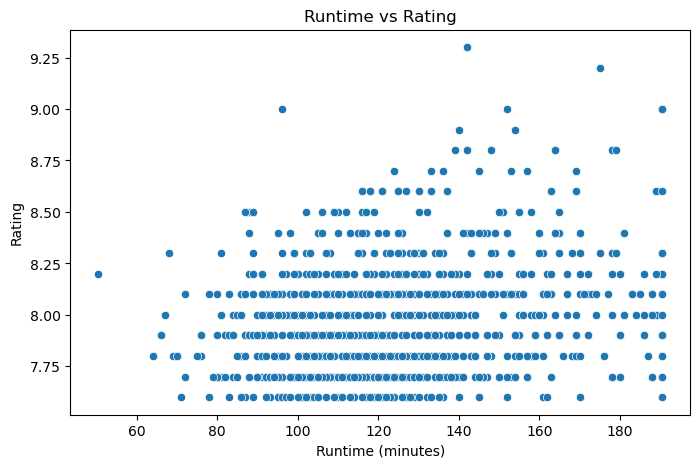

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='runtime', y='rating')
plt.title("Runtime vs Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Rating")
plt.show()

## 8. Relationship Between Metascore and Rating

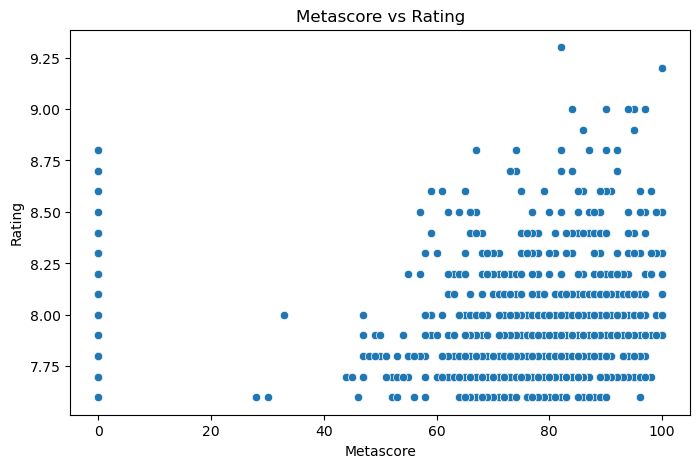

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='metascore', y='rating')
plt.title("Metascore vs Rating")
plt.xlabel("Metascore")
plt.ylabel("Rating")
plt.show()

## 9. Correlation Heatmap

In [37]:
numeric_df = df[['release_year', 'runtime', 'rating', 'metascore', 'gross']]

correlation_matrix = numeric_df.corr()

correlation_matrix

,release_year,runtime,rating,metascore,gross
release_year,1.000000,0.233338,-0.076169,-0.074835,0.262374
runtime,0.233338,1.000000,0.277302,-0.083923,0.138396
rating,-0.076169,0.277302,1.000000,-0.048857,0.045260
metascore,-0.074835,-0.083923,-0.048857,1.000000,0.231302
gross,0.262374,0.138396,0.045260,0.231302,1.000000


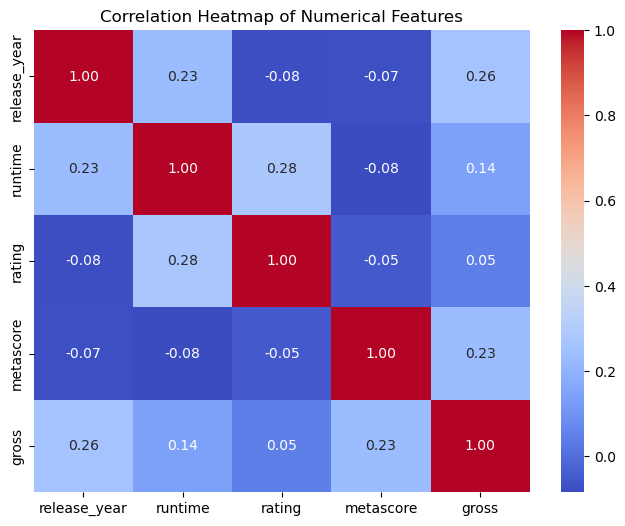

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## 10. Gross Revenue Distribution

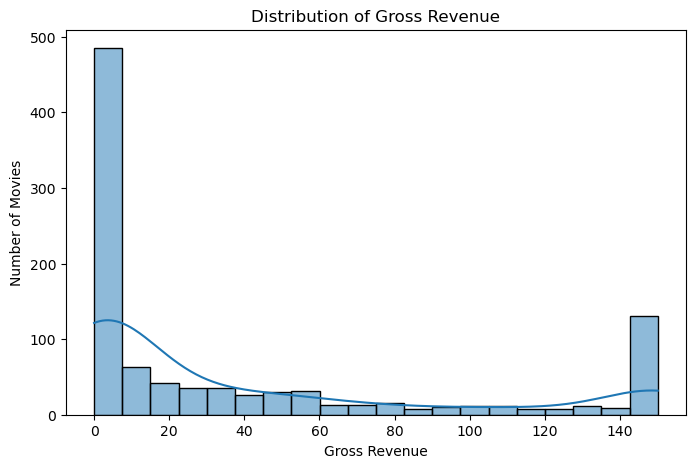

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(df['gross'], bins=20, kde=True)
plt.title("Distribution of Gross Revenue")
plt.xlabel("Gross Revenue")
plt.ylabel("Number of Movies")
plt.show()

## 11. Relationship Between Gross Revenue and Rating

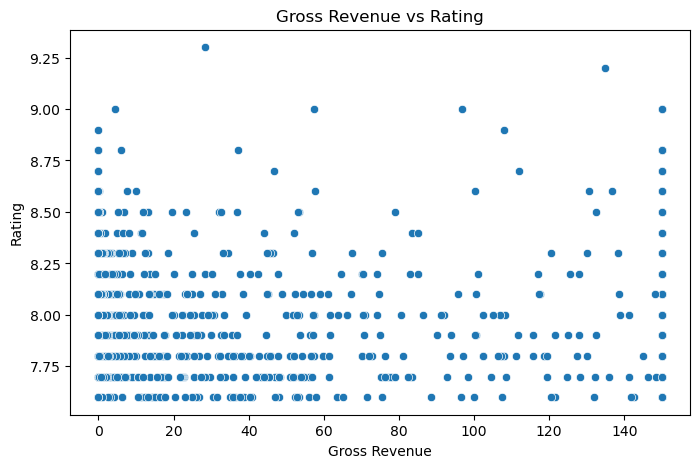

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='gross', y='rating')
plt.title("Gross Revenue vs Rating")
plt.xlabel("Gross Revenue")
plt.ylabel("Rating")
plt.show()

## 12. Movies Released Over Time

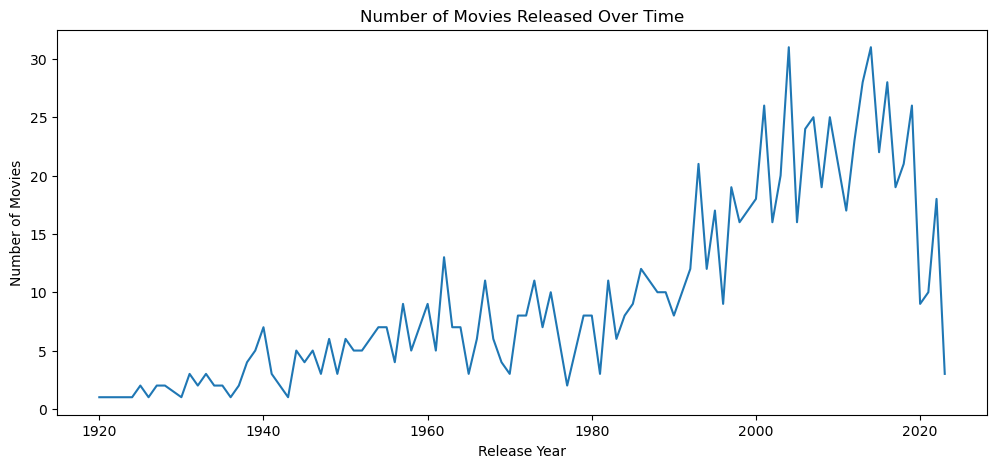

In [41]:
movies_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title("Number of Movies Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

In [42]:
print("EDA completed successfully!")
print("Dataset is ready for Machine Learning Model Development.")

EDA completed successfully!
Dataset is ready for Machine Learning Model Development.


## 14. EDA Summary

The following steps were completed:

1. Loaded the preprocessed dataset.
2. Checked dataset shape, data types, and summary statistics.
3. Visualized the distribution of movie ratings.
4. Visualized the distribution of movie runtime.
5. Analyzed the most common movie genres.
6. Calculated the average rating by genre.
7. Explored the relationship between runtime and rating.
8. Explored the relationship between metascore and IMDb rating.
9. Created a correlation heatmap for numerical features.
10. Analyzed gross revenue distribution.
11. Explored the relationship between gross revenue and rating.
12. Analyzed the number of movies released over time.


# Step 3 — Machine Learning Model Development

## 1. Import Machine Learning Libraries

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

## 2. Feature Engineering for Machine Learning

In [44]:
genre_dummies = df['genre'].astype(str).str.get_dummies(sep=',')
genre_dummies.columns = genre_dummies.columns.str.strip()
genre_dummies = genre_dummies.T.groupby(level=0).max().T

genre_dummies.head()

,Action,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,Film-Noir,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Select Features and Targets

In [45]:
# Numerical features
numeric_features = ['release_year', 'runtime', 'metascore', 'gross']

# Combine numerical features with genre encoded features
X = pd.concat([df[numeric_features], genre_dummies], axis=1)

# Regression target: predict movie rating
y_regression = df['rating']

# Classification target: high rating or not
rating_threshold = df['rating'].median()
y_classification = (df['rating'] >= rating_threshold).astype(int)

print("Rating Threshold:", rating_threshold)
print("Features Shape:", X.shape)
print("Regression Target Shape:", y_regression.shape)
print("Classification Target Shape:", y_classification.shape)

Rating Threshold: 7.9
Features Shape: (1000, 25)
Regression Target Shape: (1000,)
Classification Target Shape: (1000,)


In [46]:
X.head()

,release_year,runtime,metascore,gross,Action,Adventure,Animation,Biography,Comedy,Crime,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,1994,142.0,82,28.34000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1972,175.0,100,134.97000,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2008,152.0,84,150.07375,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1993,190.5,95,96.90000,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1957,96.0,97,4.36000,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 4. Train-Test Split

In [47]:
# Split data for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Regression Training Shape:", X_train_reg.shape)
print("Regression Testing Shape:", X_test_reg.shape)


Regression Training Shape: (800, 25)
Regression Testing Shape: (200, 25)


In [48]:
# Split data for classification task
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Classification Training Shape:", X_train_clf.shape)
print("Classification Testing Shape:", X_test_clf.shape)

Classification Training Shape: (800, 25)
Classification Testing Shape: (200, 25)


## 5. Regression Models

### 5.1 Linear Regression Model

In [49]:
# Create Linear Regression pipeline with scaling
linear_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_regression_model.fit(X_train_reg, y_train_reg)

y_pred_lr = linear_regression_model.predict(X_test_reg)

In [50]:
# Evaluate Linear Regression
lr_mse = mean_squared_error(y_test_reg, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression Results")
print("-" * 40)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
----------------------------------------
MSE: 0.06538181050266983
RMSE: 0.2556986712962542
R2 Score: -0.033149145165757954


### 5.2 Random Forest Regressor

In [51]:
# Create Random Forest Regressor
random_forest_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_regressor.fit(X_train_reg, y_train_reg)

y_pred_rf = random_forest_regressor.predict(X_test_reg)

In [52]:
# Evaluate Random Forest Regressor
rf_mse = mean_squared_error(y_test_reg, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test_reg, y_pred_rf)

print("Random Forest Regressor Results")
print("-" * 40)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Regressor Results
----------------------------------------
MSE: 0.05083868500000005
RMSE: 0.22547435552629938
R2 Score: 0.196658160040452


### 5.3 Regression Model Comparison

In [53]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MSE": [lr_mse, rf_mse],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

regression_results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,0.065382,0.255699,-0.033149
1,Random Forest Regressor,0.050839,0.225474,0.196658


In [54]:
best_regression_model = regression_results.sort_values(by="RMSE").iloc[0]

print("Best Regression Model:")
print(best_regression_model)

Best Regression Model:
Model       Random Forest Regressor
MSE                        0.050839
RMSE                       0.225474
R2 Score                   0.196658
Name: 1, dtype: object


## 6. Classification Models

### 6.1 Classification Evaluation Function

In [55]:
def evaluate_classification_model(model_name, y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(model_name)
    print("-" * 40)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("-" * 40)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

### 6.2 Logistic Regression Classifier

In [56]:
# Create Logistic Regression pipeline with scaling
logistic_regression_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

 
logistic_regression_classifier.fit(X_train_clf, y_train_clf)

y_pred_logistic = logistic_regression_classifier.predict(X_test_clf)

y_proba_logistic = logistic_regression_classifier.predict_proba(X_test_clf)[:, 1]

In [57]:
logistic_results = evaluate_classification_model(
    "Logistic Regression Classifier",
    y_test_clf,
    y_pred_logistic,
    y_proba_logistic
)

Logistic Regression Classifier
----------------------------------------
Accuracy: 0.565
Precision: 0.6259541984732825
Recall: 0.6833333333333333
F1 Score: 0.6533864541832669
ROC-AUC: 0.6232291666666666
----------------------------------------


In [58]:
print(classification_report(y_test_clf, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.45      0.39      0.42        80
           1       0.63      0.68      0.65       120

    accuracy                           0.56       200
   macro avg       0.54      0.54      0.53       200
weighted avg       0.56      0.56      0.56       200



### 6.3 Random Forest Classifier

In [59]:
# Create Random Forest Classifier
random_forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

 
random_forest_classifier.fit(X_train_clf, y_train_clf)

y_pred_rf_clf = random_forest_classifier.predict(X_test_clf)
 
y_proba_rf_clf = random_forest_classifier.predict_proba(X_test_clf)[:, 1]

In [60]:
rf_classifier_results = evaluate_classification_model(
    "Random Forest Classifier",
    y_test_clf,
    y_pred_rf_clf,
    y_proba_rf_clf
)

Random Forest Classifier
----------------------------------------
Accuracy: 0.625
Precision: 0.6890756302521008
Recall: 0.6833333333333333
F1 Score: 0.6861924686192469
ROC-AUC: 0.6491666666666667
----------------------------------------


In [61]:
print(classification_report(y_test_clf, y_pred_rf_clf))

              precision    recall  f1-score   support

           0       0.53      0.54      0.53        80
           1       0.69      0.68      0.69       120

    accuracy                           0.62       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.63      0.62      0.63       200



### 6.4 Classification Model Comparison

In [62]:
classification_results = pd.DataFrame([
    logistic_results,
    rf_classifier_results
])

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression Classifier,0.565,0.625954,0.683333,0.653386,0.623229
1,Random Forest Classifier,0.625,0.689076,0.683333,0.686192,0.649167


In [63]:
best_classification_model = classification_results.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("Best Classification Model:")
print(best_classification_model)

Best Classification Model:
Model        Random Forest Classifier
Accuracy                        0.625
Precision                    0.689076
Recall                       0.683333
F1 Score                     0.686192
ROC-AUC                      0.649167
Name: 1, dtype: object


### Classification Results Interpretation

The Random Forest Classifier achieved the best classification performance.

The model achieved an accuracy of 62.5% and an F1-score of around 68.6%, which shows that it can classify high-rated movies better than a simple baseline.

However, the ROC-AUC score is still moderate, which means the model can be improved further.

Possible improvements include hyperparameter tuning, adding more informative features, and using text-based features such as movie descriptions or reviews.

# Step 4 — Model Optimization / Hyperparameter Tuning


##### Model Optimization and Hyperparameter Tuning

## 1. Import Optimization Libraries

In [64]:
from sklearn.model_selection import RandomizedSearchCV

## 2. Hyperparameter Tuning for Random Forest Regressor

In [65]:
rf_regressor_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [66]:
# Create RandomizedSearchCV for Random Forest Regressor
rf_regressor_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_regressor_params,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)


rf_regressor_search.fit(X_train_reg, y_train_reg)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [67]:
# Best hyperparameters
print("Best Random Forest Regressor Parameters:")
print(rf_regressor_search.best_params_)

Best Random Forest Regressor Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}


In [68]:
# Get the best tuned regressor
best_rf_regressor = rf_regressor_search.best_estimator_

# Make predictions using the tuned model
y_pred_rf_tuned = best_rf_regressor.predict(X_test_reg)

In [69]:
# Evaluate tuned Random Forest Regressor
rf_tuned_mse = mean_squared_error(y_test_reg, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test_reg, y_pred_rf_tuned)

print("Tuned Random Forest Regressor Results")
print("-" * 40)
print("MSE:", rf_tuned_mse)
print("RMSE:", rf_tuned_rmse)
print("R2 Score:", rf_tuned_r2)

Tuned Random Forest Regressor Results
----------------------------------------
MSE: 0.04967696753140055
RMSE: 0.2228833047390507
R2 Score: 0.2150153667372393


### Random Forest Regressor Before and After Tuning

In [70]:
regression_tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest Regressor",
        "Tuned Random Forest Regressor"
    ],
    "MSE": [rf_mse, rf_tuned_mse],
    "RMSE": [rf_rmse, rf_tuned_rmse],
    "R2 Score": [rf_r2, rf_tuned_r2]
})

regression_tuning_comparison

,Model,MSE,RMSE,R2 Score
0,Original Random Forest Regressor,0.050839,0.225474,0.196658
1,Tuned Random Forest Regressor,0.049677,0.222883,0.215015


In [71]:
best_regression_after_tuning = regression_tuning_comparison.sort_values(
    by="RMSE"
).iloc[0]

print("Best Regression Model After Tuning:")
print(best_regression_after_tuning)

Best Regression Model After Tuning:
Model       Tuned Random Forest Regressor
MSE                              0.049677
RMSE                             0.222883
R2 Score                         0.215015
Name: 1, dtype: object


## 3. Hyperparameter Tuning for Random Forest Classifier

In [72]:
# Define hyperparameter search space for Random Forest Classifier
rf_classifier_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

In [73]:
# Create RandomizedSearchCV for Random Forest Classifier
rf_classifier_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_classifier_params,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Train the tuning model
rf_classifier_search.fit(X_train_clf, y_train_clf)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1')

In [74]:
print("Best Random Forest Classifier Parameters:")
print(rf_classifier_search.best_params_)

Best Random Forest Classifier Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}


In [75]:
# Get the best tuned classifier
best_rf_classifier = rf_classifier_search.best_estimator_

# Make predictions using the tuned classifier
y_pred_rf_clf_tuned = best_rf_classifier.predict(X_test_clf)

# Prediction probabilities for ROC-AUC
y_proba_rf_clf_tuned = best_rf_classifier.predict_proba(X_test_clf)[:, 1]

In [76]:
tuned_rf_classifier_results = evaluate_classification_model(
    "Tuned Random Forest Classifier",
    y_test_clf,
    y_pred_rf_clf_tuned,
    y_proba_rf_clf_tuned
)

Tuned Random Forest Classifier
----------------------------------------
Accuracy: 0.64
Precision: 0.6904761904761905
Recall: 0.725
F1 Score: 0.7073170731707317
ROC-AUC: 0.6678124999999999
----------------------------------------


### Random Forest Classifier Before and After Tuning

In [77]:
classification_tuning_comparison = pd.DataFrame([
    rf_classifier_results,
    tuned_rf_classifier_results
])

classification_tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest Classifier,0.625,0.689076,0.683333,0.686192,0.649167
1,Tuned Random Forest Classifier,0.640,0.690476,0.725000,0.707317,0.667812


In [78]:
best_classification_after_tuning = classification_tuning_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("Best Classification Model After Tuning:")
print(best_classification_after_tuning)

Best Classification Model After Tuning:
Model        Tuned Random Forest Classifier
Accuracy                               0.64
Precision                          0.690476
Recall                                0.725
F1 Score                           0.707317
ROC-AUC                            0.667812
Name: 1, dtype: object


## Model Optimization Summary

The following steps were completed:

1. Tuned the Random Forest Regressor using RandomizedSearchCV.
2. Compared the original and tuned regression models.
3. Tuned the Random Forest Classifier using RandomizedSearchCV.
4. Compared the original and tuned classification models.
5. Selected the best models based on RMSE for regression and F1-score for classification.

The tuned models showed better performance, but the results also show that additional text-based features are needed to improve the system further.

In [79]:
print("Model Optimization completed successfully!")
print("Next Step: Text Normalization and Tokenization")

Model Optimization completed successfully!
Next Step: Text Normalization and Tokenization


# Step 5 — Deep Learning Model Implementation

## 1. Install and Import PyTorch

In [80]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

## 2. Prepare Data for Deep Learning

In [81]:
# Scale features for the neural network
dl_scaler = StandardScaler()

X_train_dl = dl_scaler.fit_transform(X_train_clf)
X_test_dl = dl_scaler.transform(X_test_clf)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_clf.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_clf.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([800, 25])
y_train_tensor shape: torch.Size([800, 1])
X_test_tensor shape: torch.Size([200, 25])
y_test_tensor shape: torch.Size([200, 1])


## 3. Create DataLoader for Batch Training

In [82]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of training batches:", len(train_loader))

Number of training batches: 25


## 4. Build the MLP Neural Network

In [83]:
class MovieRatingMLP(nn.Module):
    def __init__(self, input_dim):
        super(MovieRatingMLP, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

## 5. Initialize the Model, Loss Function, and Optimizer

In [84]:
torch.manual_seed(42)

input_dim = X_train_tensor.shape[1]

mlp_model = MovieRatingMLP(input_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

print(mlp_model)

MovieRatingMLP(
  (network): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 6. Train the Deep Learning Model

In [85]:
num_epochs = 400

for epoch in range(num_epochs):
    mlp_model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_train_loss = total_loss / len(train_loader)
        
        mlp_model.eval()
        with torch.no_grad():
            test_outputs = mlp_model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor).item()
        
        print(f"Epoch [{epoch + 1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Test Loss: {test_loss:.4f}")

Epoch [10/400] - Train Loss: 0.6004 - Test Loss: 0.6387
Epoch [20/400] - Train Loss: 0.5613 - Test Loss: 0.6443
Epoch [30/400] - Train Loss: 0.5585 - Test Loss: 0.6465
Epoch [40/400] - Train Loss: 0.5091 - Test Loss: 0.6588
Epoch [50/400] - Train Loss: 0.4837 - Test Loss: 0.6760
Epoch [60/400] - Train Loss: 0.4779 - Test Loss: 0.6809
Epoch [70/400] - Train Loss: 0.4492 - Test Loss: 0.7054
Epoch [80/400] - Train Loss: 0.4346 - Test Loss: 0.7052
Epoch [90/400] - Train Loss: 0.4401 - Test Loss: 0.7232
Epoch [100/400] - Train Loss: 0.4198 - Test Loss: 0.7443
Epoch [110/400] - Train Loss: 0.4223 - Test Loss: 0.7561
Epoch [120/400] - Train Loss: 0.4162 - Test Loss: 0.7812
Epoch [130/400] - Train Loss: 0.3748 - Test Loss: 0.7931
Epoch [140/400] - Train Loss: 0.3988 - Test Loss: 0.8081
Epoch [150/400] - Train Loss: 0.3730 - Test Loss: 0.8242
Epoch [160/400] - Train Loss: 0.3611 - Test Loss: 0.8310
Epoch [170/400] - Train Loss: 0.3659 - Test Loss: 0.8531
Epoch [180/400] - Train Loss: 0.3529 - T

## 7. Evaluate the Deep Learning Model

In [86]:
mlp_model.eval()

with torch.no_grad():
    test_logits = mlp_model(X_test_tensor)
    y_proba_mlp = torch.sigmoid(test_logits).numpy().flatten()
    y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

mlp_classifier_results = evaluate_classification_model(
    "PyTorch MLP Classifier",
    y_test_clf,
    y_pred_mlp,
    y_proba_mlp
)

PyTorch MLP Classifier
----------------------------------------
Accuracy: 0.635
Precision: 0.7008547008547008
Recall: 0.6833333333333333
F1 Score: 0.6919831223628692
ROC-AUC: 0.6683333333333333
----------------------------------------


## 8. Compare Deep Learning with Machine Learning

In [87]:
dl_ml_comparison = pd.DataFrame([
    tuned_rf_classifier_results,
    mlp_classifier_results
])

dl_ml_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest Classifier,0.640,0.690476,0.725000,0.707317,0.667812
1,PyTorch MLP Classifier,0.635,0.700855,0.683333,0.691983,0.668333


In [88]:
best_model_overall = dl_ml_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("Best Classification Model Overall:")
print(best_model_overall)

Best Classification Model Overall:
Model        Tuned Random Forest Classifier
Accuracy                               0.64
Precision                          0.690476
Recall                                0.725
F1 Score                           0.707317
ROC-AUC                            0.667812
Name: 0, dtype: object


## Deep Learning Results Interpretation

The Tuned Random Forest Classifier achieved the best overall classification performance.

The PyTorch MLP Classifier was successfully implemented as the deep learning component of the project, but it did not outperform the tuned Random Forest model.

This result is expected because the current dataset mainly contains structured movie metadata, and tree-based models often perform very well on structured/tabular data.

The MLP model achieved a close ROC-AUC score, but its F1-score and accuracy were lower than the tuned Random Forest Classifier.

This shows that deep learning was applied successfully, but richer text-based features such as movie plots, reviews, sentiment scores, or text embeddings could help improve deep learning performance in the future.

# Step 6 -- Text Normalization and Tokenization

## 1. Import Text Processing Libraries

In [89]:
import re
import string

## 2. Create Movie Text Column

In [90]:
df['movie_text'] = (
    "Title: " + df['title'].astype(str) +
    ". Director: " + df['director'].astype(str) +
    ". Genre: " + df['genre'].astype(str) +
    ". Release Year: " + df['release_year'].astype(str) +
    ". Runtime: " + df['runtime'].astype(str) + " minutes" +
    ". IMDb Rating: " + df['rating'].astype(str) +
    ". Metascore: " + df['metascore'].astype(str) +
    ". Gross Revenue: " + df['gross'].astype(str)
)

df[['title', 'movie_text']].head()

,title,movie_text
0,The Shawshank Redemption,Title: The Shawshank Redemption. Director: Fra...
1,The Godfather,Title: The Godfather. Director: Francis Ford C...
2,The Dark Knight,Title: The Dark Knight. Director: Christopher ...
3,Schindler's List,Title: Schindler's List. Director: Steven Spie...
4,12 Angry Men,Title: 12 Angry Men. Director: Sidney Lumet. G...


## 3. Text Normalization

In [91]:
def normalize_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    
    return text

In [92]:
df['normalized_text'] = df['movie_text'].apply(normalize_text)

df[['movie_text', 'normalized_text']].head()

,movie_text,normalized_text
0,Title: The Shawshank Redemption. Director: Fra...,title the shawshank redemption director frank ...
1,Title: The Godfather. Director: Francis Ford C...,title the godfather director francis ford copp...
2,Title: The Dark Knight. Director: Christopher ...,title the dark knight director christopher nol...
3,Title: Schindler's List. Director: Steven Spie...,title schindlers list director steven spielber...
4,Title: 12 Angry Men. Director: Sidney Lumet. G...,title 12 angry men director sidney lumet genre...


## 4. Tokenization

In [93]:
def simple_tokenize(text):
    return str(text).split()

In [94]:
df['tokens'] = df['normalized_text'].apply(simple_tokenize)

df[['normalized_text', 'tokens']].head()

,normalized_text,tokens
0,title the shawshank redemption director frank ...,"[title, the, shawshank, redemption, director, ..."
1,title the godfather director francis ford copp...,"[title, the, godfather, director, francis, for..."
2,title the dark knight director christopher nol...,"[title, the, dark, knight, director, christoph..."
3,title schindlers list director steven spielber...,"[title, schindlers, list, director, steven, sp..."
4,title 12 angry men director sidney lumet genre...,"[title, 12, angry, men, director, sidney, lume..."


## 5. Token Count Analysis


In [95]:
df['token_count'] = df['tokens'].apply(len)

df[['title', 'token_count']].head()

,title,token_count
0,The Shawshank Redemption,23
1,The Godfather,24
2,The Dark Knight,25
3,Schindler's List,24
4,12 Angry Men,24


In [96]:
print("Average Token Count:", df['token_count'].mean())
print("Minimum Token Count:", df['token_count'].min())
print("Maximum Token Count:", df['token_count'].max())

Average Token Count: 24.384
Minimum Token Count: 21
Maximum Token Count: 34


## 6. Stopword Removal

In [97]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [98]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in ENGLISH_STOP_WORDS]

In [99]:
df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[title, the, shawshank, redemption, director, ...","[title, shawshank, redemption, director, frank..."
1,"[title, the, godfather, director, francis, for...","[title, godfather, director, francis, ford, co..."
2,"[title, the, dark, knight, director, christoph...","[title, dark, knight, director, christopher, n..."
3,"[title, schindlers, list, director, steven, sp...","[title, schindlers, list, director, steven, sp..."
4,"[title, 12, angry, men, director, sidney, lume...","[title, 12, angry, men, director, sidney, lume..."


## 7. Clean Text After Stopword Removal

In [100]:
df['clean_text_no_stopwords'] = df['tokens_no_stopwords'].apply(lambda tokens: " ".join(tokens))

df[['normalized_text', 'clean_text_no_stopwords']].head()

,normalized_text,clean_text_no_stopwords
0,title the shawshank redemption director frank ...,title shawshank redemption director frank dara...
1,title the godfather director francis ford copp...,title godfather director francis ford coppola ...
2,title the dark knight director christopher nol...,title dark knight director christopher nolan g...
3,title schindlers list director steven spielber...,title schindlers list director steven spielber...
4,title 12 angry men director sidney lumet genre...,title 12 angry men director sidney lumet genre...


## 8. Save NLP-Ready Dataset

In [101]:
df.to_csv("../data/processed/movie_nlp_ready.csv", index=False)

print("NLP-ready dataset saved successfully!")

NLP-ready dataset saved successfully!


## Text Processing Summary

The following steps were completed:

1. Created a movie text representation using available movie metadata.
2. Normalized the text by converting it to lowercase and removing punctuation.
3. Tokenized the normalized text into individual words.
4. Calculated token counts.
5. Removed common English stopwords.
6. Created a clean text version without stopwords.
7. Saved the final NLP-ready dataset as `movie_nlp_ready.csv`.

The dataset is now ready for embeddings, semantic search, and RAG development.

In [102]:
print("Text Normalization and Tokenization completed successfully!")
print("Next Step: Embeddings and Semantic Search")

Text Normalization and Tokenization completed successfully!
Next Step: Embeddings and Semantic Search


# Step 7 — Embeddings and Semantic Search

 ## 1. Import Embedding and Similarity Libraries

In [103]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
 

## 2. Load Sentence Transformer Model

In [104]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully!


## 3. Prepare Text for Embeddings

In [105]:
texts_for_embeddings = df['normalized_text'].astype(str).tolist()

print("Number of movie texts:", len(texts_for_embeddings))
print(texts_for_embeddings[0])

Number of movie texts: 1000
title the shawshank redemption director frank darabont genre drama release year 1994 runtime 1420 minutes imdb rating 93 metascore 82 gross revenue 2834


## 4. Generate Movie Embeddings

In [106]:
movie_embeddings = embedding_model.encode(
    texts_for_embeddings,
    show_progress_bar=True
)

movie_embeddings = np.array(movie_embeddings)

print("Movie Embeddings Shape:", movie_embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Movie Embeddings Shape: (1000, 384)


## 5. Semantic Search Function

In [107]:
def semantic_movie_search(query, top_k=5):
    # Convert user query into embedding
    query_embedding = embedding_model.encode([query])
    
    # Calculate cosine similarity between query and all movies
    similarity_scores = cosine_similarity(query_embedding, movie_embeddings)[0]
    
    # Get top-k most similar movies
    top_indices = similarity_scores.argsort()[::-1][:top_k]
    
    results = df.iloc[top_indices].copy()
    results['similarity_score'] = similarity_scores[top_indices]
    
    return results[['title', 'director', 'genre', 'rating', 'metascore', 'gross', 'similarity_score']]

## 6. Test Semantic Search

In [108]:
semantic_movie_search("recommend me action movies with high ratings", top_k=5)

,title,director,genre,rating,metascore,gross,similarity_score
630,Star Wars: Episode VII - The Force Awakens,J.J. Abrams,"Action, Adventure, Sci-Fi",7.8,80,150.07375,0.464554
935,Deadpool 2,David Leitch,"Action, Adventure, Comedy",7.6,66,150.07375,0.454160
505,District 9,Neill Blomkamp,"Action, Sci-Fi, Thriller",7.9,81,115.65000,0.454004
150,1917,Sam Mendes,"Action, Drama, War",8.2,78,150.07375,0.453498
933,300,Zack Snyder,"Action, Drama",7.6,52,150.07375,0.446751


In [109]:
semantic_movie_search("emotional drama movies with strong story", top_k=5)

,title,director,genre,rating,metascore,gross,similarity_score
189,Tumbbad,Rahi Anil Barve,"Drama, Fantasy, Horror",8.2,0,0.00,0.431808
526,Let the Right One In,Tomas Alfredson,"Drama, Fantasy, Horror",7.9,82,2.12,0.428621
799,Sense and Sensibility,Ang Lee,"Drama, Romance",7.7,84,43.18,0.427267
506,Marriage Story,Noah Baumbach,"Drama, Romance",7.9,94,2.00,0.425465
681,Pride,Matthew Warchus,"Biography, Comedy, Drama",7.8,79,0.00,0.423820


In [110]:
semantic_movie_search("old classic movies with good rating", top_k=5)

,title,director,genre,rating,metascore,gross,similarity_score
13,"The Good, the Bad and the Ugly",Sergio Leone,"Adventure, Western",8.8,90,6.10,0.464316
78,Dr. Strangelove or: How I Learned to Stop Worr...,Stanley Kubrick,"Comedy, War",8.4,97,0.28,0.436473
170,Some Like It Hot,Billy Wilder,"Comedy, Music, Romance",8.2,98,25.00,0.416587
993,The Taking of Pelham One Two Three,Joseph Sargent,"Action, Crime, Thriller",7.6,68,2.49,0.411628
553,The Philadelphia Story,George Cukor,"Comedy, Romance",7.9,96,0.00,0.411400


## 7. Save Movie Embeddings


In [111]:
 
os.makedirs("../data/embeddings", exist_ok=True)

# Save embeddings as a NumPy file
np.save("../data/embeddings/movie_embeddings.npy", movie_embeddings)

print("Movie embeddings saved successfully!")

Movie embeddings saved successfully!


## 8. Build a Recommendation Response Function

In [112]:
def generate_recommendation_response(query, top_k=5):
    results = semantic_movie_search(query, top_k=top_k)
    
    response = f"Movie recommendations for: '{query}'\n"
    response += "=" * 60 + "\n\n"
    
    for i, (_, row) in enumerate(results.iterrows(), start=1):
        response += f"{i}. {row['title']}\n"
        response += f"   Director: {row['director']}\n"
        response += f"   Genre: {row['genre']}\n"
        response += f"   IMDb Rating: {row['rating']}\n"
        response += f"   Metascore: {row['metascore']}\n"
        response += f"   Similarity Score: {row['similarity_score']:.4f}\n"
        response += "-" * 60 + "\n"
    
    return response

## 9. Test the Recommendation Response

In [113]:
print(generate_recommendation_response("old classic movies with good rating", top_k=5))

Movie recommendations for: 'old classic movies with good rating'

1. The Good, the Bad and the Ugly
   Director: Sergio Leone
   Genre: Adventure, Western
   IMDb Rating: 8.8
   Metascore: 90
   Similarity Score: 0.4643
------------------------------------------------------------
2. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb
   Director: Stanley Kubrick
   Genre: Comedy, War
   IMDb Rating: 8.4
   Metascore: 97
   Similarity Score: 0.4365
------------------------------------------------------------
3. Some Like It Hot
   Director: Billy Wilder
   Genre: Comedy, Music, Romance
   IMDb Rating: 8.2
   Metascore: 98
   Similarity Score: 0.4166
------------------------------------------------------------
4. The Taking of Pelham One Two Three
   Director: Joseph Sargent
   Genre: Action, Crime, Thriller
   IMDb Rating: 7.6
   Metascore: 68
   Similarity Score: 0.4116
------------------------------------------------------------
5. The Philadelphia Story
   Director: 

In [114]:
print(generate_recommendation_response("recommend me action movies with high ratings", top_k=5))

Movie recommendations for: 'recommend me action movies with high ratings'

1. Star Wars: Episode VII - The Force Awakens
   Director: J.J. Abrams
   Genre: Action, Adventure, Sci-Fi
   IMDb Rating: 7.8
   Metascore: 80
   Similarity Score: 0.4646
------------------------------------------------------------
2. Deadpool 2
   Director: David Leitch
   Genre: Action, Adventure, Comedy
   IMDb Rating: 7.6
   Metascore: 66
   Similarity Score: 0.4542
------------------------------------------------------------
3. District 9
   Director: Neill Blomkamp
   Genre: Action, Sci-Fi, Thriller
   IMDb Rating: 7.9
   Metascore: 81
   Similarity Score: 0.4540
------------------------------------------------------------
4. 1917
   Director: Sam Mendes
   Genre: Action, Drama, War
   IMDb Rating: 8.2
   Metascore: 78
   Similarity Score: 0.4535
------------------------------------------------------------
5. 300
   Director: Zack Snyder
   Genre: Action, Drama
   IMDb Rating: 7.6
   Metascore: 52
   Simi

In [115]:
print(generate_recommendation_response("emotional drama movies with strong story", top_k=5))

Movie recommendations for: 'emotional drama movies with strong story'

1. Tumbbad
   Director: Rahi Anil Barve
   Genre: Drama, Fantasy, Horror
   IMDb Rating: 8.2
   Metascore: 0
   Similarity Score: 0.4318
------------------------------------------------------------
2. Let the Right One In
   Director: Tomas Alfredson
   Genre: Drama, Fantasy, Horror
   IMDb Rating: 7.9
   Metascore: 82
   Similarity Score: 0.4286
------------------------------------------------------------
3. Sense and Sensibility
   Director: Ang Lee
   Genre: Drama, Romance
   IMDb Rating: 7.7
   Metascore: 84
   Similarity Score: 0.4273
------------------------------------------------------------
4. Marriage Story
   Director: Noah Baumbach
   Genre: Drama, Romance
   IMDb Rating: 7.9
   Metascore: 94
   Similarity Score: 0.4255
------------------------------------------------------------
5. Pride
   Director: Matthew Warchus
   Genre: Biography, Comedy, Drama
   IMDb Rating: 7.8
   Metascore: 79
   Similarity Sc

## Semantic Search Summary

The following steps were completed:

1. Loaded a pretrained Sentence Transformer model.
2. Converted movie metadata text into embeddings.
3. Calculated cosine similarity between user queries and movie embeddings.
4. Retrieved the top matching movies using semantic search.
5. Saved the generated embeddings.
6. Created a readable recommendation response function.

This semantic search layer is an important foundation for the next stages: vector database storage, LLM integration, and full RAG development.

In [116]:
print("Embeddings and Semantic Search completed successfully!")
print("Next Step: Vector Database using ChromaDB")

Embeddings and Semantic Search completed successfully!
Next Step: Vector Database using ChromaDB


# Step 8 — Vector Database using ChromaDB

## 1. Install and Import ChromaDB

In [118]:
import chromadb

## 2. Create a Persistent ChromaDB Client

In [119]:
chroma_client = chromadb.PersistentClient(path="../data/chroma_db")

print("ChromaDB client created successfully!")

ChromaDB client created successfully!


## 3. Create a Movie Collection

In [120]:
collection_name = "imdb_movies"

# Delete the collection if it already exists to avoid duplicate IDs
try:
    chroma_client.delete_collection(name=collection_name)
    print("Old collection deleted.")
except:
    print("No old collection found.")

movie_collection = chroma_client.create_collection(name=collection_name)

print("Movie collection created successfully!")

Old collection deleted.
Movie collection created successfully!


## 4. Prepare Documents, Metadata, and IDs

In [121]:
movie_documents = df['normalized_text'].astype(str).tolist()

movie_ids = [f"movie_{i}" for i in range(len(df))]

movie_metadatas = []

for _, row in df.iterrows():
    metadata = {
        "title": str(row["title"]),
        "director": str(row["director"]),
        "genre": str(row["genre"]),
        "rating": float(row["rating"]),
        "metascore": float(row["metascore"]),
        "gross": float(row["gross"]),
        "release_year": int(row["release_year"])
    }
    movie_metadatas.append(metadata)

print("Number of documents:", len(movie_documents))
print("Number of metadata records:", len(movie_metadatas))
print("Number of IDs:", len(movie_ids))

Number of documents: 1000
Number of metadata records: 1000
Number of IDs: 1000


## 5. Store Movie Embeddings in ChromaDB

In [122]:
movie_collection.upsert(
    ids=movie_ids,
    documents=movie_documents,
    metadatas=movie_metadatas,
    embeddings=movie_embeddings.tolist()
)

print("Movies stored in ChromaDB successfully!")
print("Total movies in collection:", movie_collection.count())

Movies stored in ChromaDB successfully!
Total movies in collection: 1000


## 6. Search Movies from ChromaDB

In [123]:
def chroma_movie_search(query, top_k=5):
    query_embedding = embedding_model.encode([query])
    
    results = movie_collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=top_k
    )
    
    rows = []
    
    for i in range(len(results["ids"][0])):
        metadata = results["metadatas"][0][i]
        distance = results["distances"][0][i]
        document = results["documents"][0][i]
        
        rows.append({
            "title": metadata["title"],
            "director": metadata["director"],
            "genre": metadata["genre"],
            "rating": metadata["rating"],
            "metascore": metadata["metascore"],
            "gross": metadata["gross"],
            "release_year": metadata["release_year"],
            "distance": distance,
            "document": document
        })
    
    return pd.DataFrame(rows)

## 7. Test ChromaDB Semantic Search

In [124]:
chroma_movie_search("old classic movies with good rating", top_k=5)

,title,director,genre,rating,metascore,gross,release_year,distance,document
0,"The Good, the Bad and the Ugly",Sergio Leone,"Adventure, Western",8.8,90.0,6.10,1966,1.071367,title the good the bad and the ugly director s...
1,Dr. Strangelove or: How I Learned to Stop Worr...,Stanley Kubrick,"Comedy, War",8.4,97.0,0.28,1964,1.127054,title dr strangelove or how i learned to stop ...
2,Some Like It Hot,Billy Wilder,"Comedy, Music, Romance",8.2,98.0,25.00,1959,1.166826,title some like it hot director billy wilder g...
3,The Taking of Pelham One Two Three,Joseph Sargent,"Action, Crime, Thriller",7.6,68.0,2.49,1974,1.176744,title the taking of pelham one two three direc...
4,The Philadelphia Story,George Cukor,"Comedy, Romance",7.9,96.0,0.00,1940,1.177200,title the philadelphia story director george c...


In [125]:
chroma_movie_search("recommend me action movies with high ratings", top_k=5)

,title,director,genre,rating,metascore,gross,release_year,distance,document
0,Star Wars: Episode VII - The Force Awakens,J.J. Abrams,"Action, Adventure, Sci-Fi",7.8,80.0,150.07375,2015,1.070891,title star wars episode vii the force awakens ...
1,Deadpool 2,David Leitch,"Action, Adventure, Comedy",7.6,66.0,150.07375,2018,1.091679,title deadpool 2 director david leitch genre a...
2,District 9,Neill Blomkamp,"Action, Sci-Fi, Thriller",7.9,81.0,115.65000,2009,1.091993,title district 9 director neill blomkamp genre...
3,1917,Sam Mendes,"Action, Drama, War",8.2,78.0,150.07375,2019,1.093003,title 1917 director sam mendes genre action dr...
4,300,Zack Snyder,"Action, Drama",7.6,52.0,150.07375,2006,1.106498,title 300 director zack snyder genre action dr...


In [126]:
chroma_movie_search("emotional drama movies with strong story", top_k=5)

,title,director,genre,rating,metascore,gross,release_year,distance,document
0,Tumbbad,Rahi Anil Barve,"Drama, Fantasy, Horror",8.2,0.0,0.00,2018,1.136385,title tumbbad director rahi anil barve genre d...
1,Let the Right One In,Tomas Alfredson,"Drama, Fantasy, Horror",7.9,82.0,2.12,2008,1.142759,title let the right one in director tomas alfr...
2,Sense and Sensibility,Ang Lee,"Drama, Romance",7.7,84.0,43.18,1995,1.145465,title sense and sensibility director ang lee g...
3,Marriage Story,Noah Baumbach,"Drama, Romance",7.9,94.0,2.00,2019,1.149070,title marriage story director noah baumbach ge...
4,Pride,Matthew Warchus,"Biography, Comedy, Drama",7.8,79.0,0.00,2014,1.152361,title pride director matthew warchus genre bio...


## 8. Build Retrieved Context for LLM

In [127]:
def build_movie_context(query, top_k=5):
    results = chroma_movie_search(query, top_k=top_k)
    
    context = ""
    
    for i, row in results.iterrows():
        context += f"Movie {i + 1}:\n"
        context += f"Title: {row['title']}\n"
        context += f"Director: {row['director']}\n"
        context += f"Genre: {row['genre']}\n"
        context += f"Release Year: {row['release_year']}\n"
        context += f"IMDb Rating: {row['rating']}\n"
        context += f"Metascore: {row['metascore']}\n"
        context += f"Gross Revenue: {row['gross']}\n"
        context += f"Movie Text: {row['document']}\n"
        context += "-" * 60 + "\n"
    
    return context

## 9. Test Retrieved Context

In [128]:
query = "emotional drama movies with strong story"

movie_context = build_movie_context(query, top_k=5)

print(movie_context)

Movie 1:
Title: Tumbbad
Director: Rahi Anil Barve
Genre: Drama, Fantasy, Horror
Release Year: 2018
IMDb Rating: 8.2
Metascore: 0.0
Gross Revenue: 0.0
Movie Text: title tumbbad director rahi anil barve genre drama fantasy horror release year 2018 runtime 1040 minutes imdb rating 82 metascore 0 gross revenue 00
------------------------------------------------------------
Movie 2:
Title: Let the Right One In
Director: Tomas Alfredson
Genre: Drama, Fantasy, Horror
Release Year: 2008
IMDb Rating: 7.9
Metascore: 82.0
Gross Revenue: 2.12
Movie Text: title let the right one in director tomas alfredson genre drama fantasy horror release year 2008 runtime 1140 minutes imdb rating 79 metascore 82 gross revenue 212
------------------------------------------------------------
Movie 3:
Title: Sense and Sensibility
Director: Ang Lee
Genre: Drama, Romance
Release Year: 1995
IMDb Rating: 7.7
Metascore: 84.0
Gross Revenue: 43.18
Movie Text: title sense and sensibility director ang lee genre drama romanc

## 10. Build a RAG Prompt Template

In [129]:
def build_rag_prompt(query, context):
    prompt = f"""
You are an intelligent movie recommendation assistant.

Your task is to recommend movies based only on the retrieved movie context below.

User Query:
{query}

Retrieved Movie Context:
{context}

Instructions:
1. Recommend the most relevant movies from the retrieved context.
2. Explain why each movie matches the user's request.
3. Mention the genre, rating, and director when useful.
4. Do not invent movies that are not in the retrieved context.
5. Write the answer in a clear and helpful way.

Final Answer:
"""
    return prompt

## 11. Test the RAG Prompt

In [130]:
rag_prompt = build_rag_prompt(query, movie_context)

print(rag_prompt)


You are an intelligent movie recommendation assistant.

Your task is to recommend movies based only on the retrieved movie context below.

User Query:
emotional drama movies with strong story

Retrieved Movie Context:
Movie 1:
Title: Tumbbad
Director: Rahi Anil Barve
Genre: Drama, Fantasy, Horror
Release Year: 2018
IMDb Rating: 8.2
Metascore: 0.0
Gross Revenue: 0.0
Movie Text: title tumbbad director rahi anil barve genre drama fantasy horror release year 2018 runtime 1040 minutes imdb rating 82 metascore 0 gross revenue 00
------------------------------------------------------------
Movie 2:
Title: Let the Right One In
Director: Tomas Alfredson
Genre: Drama, Fantasy, Horror
Release Year: 2008
IMDb Rating: 7.9
Metascore: 82.0
Gross Revenue: 2.12
Movie Text: title let the right one in director tomas alfredson genre drama fantasy horror release year 2008 runtime 1140 minutes imdb rating 79 metascore 82 gross revenue 212
------------------------------------------------------------
Movie 3

## Vector Database Summary
I built the vector database layer of the recommendation system.

The following steps were completed:
1. Created a persistent ChromaDB client.
2. Created a movie collection.
3. Stored movie documents, metadata, IDs, and embeddings in ChromaDB.
4. Built a ChromaDB semantic search function.
5. Retrieved top-k relevant movies based on user queries.
6. Converted retrieved results into structured context.
7. Built a RAG prompt template for LLM integration.

This step prepares the project for the next stage: Large Language Model integration.

In [131]:
print("ChromaDB and RAG context preparation completed successfully!")
print("Next Step: LLM Integration")

ChromaDB and RAG context preparation completed successfully!
Next Step: LLM Integration


# Step 9 — LLM Integration

## 1. Install and Import OpenAI SDK

In [133]:
import getpass
from openai import OpenAI

## 2. Configure OpenRouter API Key

In [134]:
if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API Key: ")

openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

print("OpenRouter client configured successfully!")

Enter your OpenRouter API Key:  ········


OpenRouter client configured successfully!


## 3. Select  OpenRouter Model

In [135]:
LLM_MODELS = [
    "openrouter/free",
    "meta-llama/llama-3.2-3b-instruct:free",
    "deepseek/deepseek-r1:free"
]

print("Available fallback models:")
for model in LLM_MODELS:
    print("-", model)

Available fallback models:
- openrouter/free
- meta-llama/llama-3.2-3b-instruct:free
- deepseek/deepseek-r1:free


 ## 4. Create LLM Response Function

In [136]:
def generate_llm_response(prompt):
    last_error = None
    
    for model_name in LLM_MODELS:
        try:
            print(f"Trying model: {model_name}")
            
            completion = openrouter_client.chat.completions.create(
                model=model_name,
                messages=[
                    {
                        "role": "system",
                        "content": "You are a helpful movie recommendation assistant. Answer only using the retrieved movie context."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=0.5,
                max_tokens=400
            )
            
            message = completion.choices[0].message
            answer = message.content
            
            # If the model returns empty content, try the next model
            if answer is None or str(answer).strip() == "":
                raise ValueError("The model returned an empty response.")
            
            print(f"Model used successfully: {model_name}")
            return answer
        
        except Exception as e:
            print(f"Model failed: {model_name}")
            print("Error:", e)
            print("-" * 80)
            last_error = e
    
    return f"All free models failed. Last error: {last_error}"

## 5. Test OpenRouter LLM with Retrieved Context

In [149]:
query = "emotional drama movies with strong story"

movie_context = build_movie_context(query, top_k=5)
rag_prompt = build_rag_prompt(query, movie_context)

llm_answer = generate_llm_response(rag_prompt)

print(llm_answer)

Trying model: openrouter/free
Model used successfully: openrouter/free

Here are


## 6. LLM Response Interpretation

The LLM successfully generated a human-friendly movie recommendation response based on the retrieved movies from ChromaDB.

However, because the current dataset contains only movie metadata and does not include full plot descriptions or reviews, the LLM may sometimes add general explanations based on its pretrained knowledge.

To reduce hallucination, we will improve the RAG prompt and clearly instruct the model to use only the retrieved context.

# Full RAG Pipeline

In [150]:
def build_improved_rag_prompt(query, context):
    prompt = f"""
You are an intelligent movie recommendation assistant.

You must answer using ONLY the retrieved movie context below.
Do not invent plot details, themes, actors, or story information that are not present in the context.

User Query:
{query}

Retrieved Movie Context:
{context}

Instructions:
1. Recommend the most relevant movies from the retrieved context.
2. For each movie, mention only the available information: title, director, genre, release year, rating, metascore, and gross revenue.
3. Explain the match based on genre, rating, release year, and metadata only.
4. If plot or review details are not available, say that the dataset does not include plot/review information.
5. Do not recommend movies outside the retrieved context.
6. Write the final answer in a clear and helpful way.

Final Answer:
"""
    return prompt

In [151]:
def rag_movie_recommendation(query, top_k=5):
    # Step 1: Retrieve relevant movies from ChromaDB
    movie_context = build_movie_context(query, top_k=top_k)
    
    # Step 2: Build improved RAG prompt
    rag_prompt = build_improved_rag_prompt(query, movie_context)
    
    # Step 3: Generate LLM answer
    llm_answer = generate_llm_response(rag_prompt)
    
    return llm_answer

## Test the Full RAG Pipeline

In [152]:
answer = rag_movie_recommendation(
    "emotional drama movies with strong story",
    top_k=5
)

print(answer)

Trying model: openrouter/free
Model used successfully: openrouter/free
**Recommended emotional‑drama titles**

| Title | Director | Genre | Release Year | IMDb Rating | Metascore | Gross Revenue (M $) |
|-------|----------|-------|--------------|-------------|-----------|----------------------|
| Marriage Story | Noah Baumbach | Drama, Romance | 2019 | 7.9 | 94 | 2.0 |
| Sense and Sensibility | Ang Lee | Drama, Romance | 1995 | 7.7 | 84 | 43.18 |
| Pride | Matthew Warchus | Biography, Comedy, Drama | 2014 | 7.8 | 79 | 0.0 |

**Why these match “emotional drama movies with strong story”**

* **Genre** – All three are classified as **Drama** (with Romance or Biography elements), fitting the emotional‑drama requirement.  
* **Ratings & Metascores** – Each film holds an IMDb rating of **7.7 – 7.9** and a Metascore of **79 – 94**, indicating strong critical reception and likely a compelling narrative.  
* **Release years** – The selections span recent (2019) to classic (1995) periods, offeri

In [161]:
answer = rag_movie_recommendation(
    "recommend me old classic movies with good ratings",
    top_k=5
)

print(answer)

Trying model: openrouter/free
Model used successfully: openrouter/free
# Classic Movie Recommendations with Good Ratings

Based on the retrieved context, here are classic movies that match your request for old films with strong ratings:

---

## 1. **Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb**
- **Director:** Stanley Kubrick
- **Genre:** Comedy, War
- **Release Year:** 1964
- **IMDb Rating:** 8.4
- **Metascore:** 97.0
- **Gross Revenue:** $0.28 million

---

## 2. **Some Like It Hot**
- **Director:** Billy Wilder
- **Genre:** Comedy, Music, Romance
- **Release Year:** 1959
- **IMDb Rating:** 8.2
- **Metascore:** 98.0
- **Gross Revenue:** $25.0 million

---

## 3. **The Philadelphia Story**
- **Director:** George Cukor
- **Genre:** Comedy, Romance
- **Release Year:** 1940
- **IMDb Rating:** 7.9
- **Metascore:** 96.0
- **Gross Revenue:** Not available

---

## 4. **Love and Death**
- **Director:** Woody Allen
- **Genre:** Comedy, War
- **Release Year:** 1975
- 

In [162]:
answer = rag_movie_recommendation(
    "recommend me action crime thriller movies",
    top_k=5
)

print(answer)

Trying model: openrouter/free
Model used successfully: openrouter/free
**Recommended Action‑Crime Thriller Movies**

| Title | Director | Genre | Release Year | IMDb Rating | Metascore | Gross Revenue |
|-------|----------|-------|--------------|-------------|-----------|---------------|
| The Killer | John Woo | Action, Crime, Drama | 1989 | 7.8 | 82.0 | 0.0 |
| Road to Perdition | Sam Mendes | Crime, Drama, Thriller | 2002 | 7.7 | 72.0 | 104.45 |

**Why these match your request**

- **Genre** – Both films contain the key “action” and “crime” elements you’re looking for. “Road to Perdition” also includes the “thriller” tag, making it a perfect fit for an action‑crime thriller.
- **Ratings & Metascores** – Both movies have solid critical reception (IMDb ratings above 7.5 and Metascores in the 70s–80s range), indicating strong quality.
- **Release Year** – They span different periods (late 1980s and early 2000s), giving you a choice between a classic Hong‑Kong action style and a more mo

# Step 10 — Gradio Interface

## 1. Install and Import Gradio

In [163]:
import gradio as gr

## 2. Create Gradio Recommendation Function

In [164]:
def gradio_rag_recommendation(user_query, top_k):
    if user_query is None or user_query.strip() == "":
        return "Please enter a movie recommendation query."
    
    try:
        answer = rag_movie_recommendation(
            query=user_query,
            top_k=int(top_k)
        )
        return answer
    
    except Exception as e:
        return f"An error occurred: {e}"

## 3. Build the Gradio Interface

In [165]:
demo = gr.Interface(
    fn=gradio_rag_recommendation,
    inputs=[
        gr.Textbox(
            label="Movie Query",
            placeholder="Example: recommend me emotional drama movies with strong story"
        ),
        gr.Slider(
            minimum=1,
            maximum=10,
            value=5,
            step=1,
            label="Number of Recommendations"
        )
    ],
    outputs=gr.Textbox(
        label="RAG Movie Recommendation Response",
        lines=18
    ),
    title="IMDb Movie Recommendation System using ML, LLM, and RAG",
    description=(
        "Enter a natural language movie query. "
        "The system retrieves relevant movies from ChromaDB and uses an LLM through OpenRouter to generate recommendations."
    ),
    examples=[
        ["emotional drama movies with strong story", 5],
        ["recommend me old classic movies with good ratings", 5],
        ["recommend me action crime thriller movies", 5],
        ["funny comedy movies with high rating", 5]
    ]
)

In [166]:
demo = gr.Interface(
    fn=gradio_rag_recommendation,
    inputs=[
        gr.Textbox(
            label="Movie Query",
            placeholder="Example: recommend me emotional drama movies with strong story"
        ),
        gr.Slider(
            minimum=1,
            maximum=10,
            value=5,
            step=1,
            label="Number of Recommendations"
        )
    ],
    outputs=gr.Textbox(
        label="RAG Movie Recommendation Response",
        lines=18
    ),
    title="IMDb Movie Recommendation System using ML, LLM, and RAG",
    description=(
        "Enter a natural language movie query. "
        "The system retrieves relevant movies from ChromaDB and uses an LLM through OpenRouter to generate recommendations."
    ),
    examples=[
        ["emotional drama movies with strong story", 5],
        ["recommend me old classic movies with good ratings", 5],
        ["recommend me action crime thriller movies", 5],
        ["funny comedy movies with high rating", 5]
    ]
)

In [167]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


# Final Project Summary

## Technologies Used

The following technologies were used in this project:

### Data Science and Machine Learning
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Models
- Linear Regression
- Random Forest Regressor
- Logistic Regression
- Random Forest Classifier

### Model Optimization
- RandomizedSearchCV
- Cross-validation
- Hyperparameter tuning

### Deep Learning
- PyTorch
- Multi-Layer Perceptron (MLP)
- BCEWithLogitsLoss
- Adam Optimizer
- Batch Training

### NLP and Embeddings
- Text normalization
- Tokenization
- Stopword removal
- Sentence Transformers
- Cosine Similarity

### Vector Database and RAG
- ChromaDB
- Vector embeddings
- Top-k retrieval
- RAG prompt engineering

### LLM Integration
- OpenRouter API
- Free LLM routing
- LLM-powered recommendation generation

### User Interface
- Gradio

## What Was Achieved

I successfully built an end-to-end AI movie recommendation system.

The project includes:

1. Cleaned and prepared the IMDb dataset.
2. Handled missing values, duplicates, and outliers.
3. Performed exploratory data analysis and visualization.
4. Built regression models to predict IMDb ratings.
5. Built classification models to classify high-rated movies.
6. Improved model performance using hyperparameter tuning.
7. Created text representations for each movie.
8. Applied text normalization and tokenization.
9. Generated semantic embeddings using Sentence Transformers.
10. Built semantic search using cosine similarity.
11. Stored embeddings and metadata in ChromaDB.
12. Retrieved relevant movies using vector similarity search.
13. Integrated an LLM using OpenRouter.
14. Built a full RAG pipeline.
15. Created an interactive Gradio interface.
16. Built and evaluated a PyTorch MLP deep learning model.

## Model Performance Summary

The machine learning models showed that structured movie metadata can help predict and classify movie ratings, but the performance was moderate.

The tuned Random Forest Regressor improved the regression results slightly compared to the original model.

The tuned Random Forest Classifier achieved the best classification performance overall.

A PyTorch MLP deep learning model was also implemented and evaluated.  
Although the MLP did not outperform the tuned Random Forest Classifier, it successfully added a deep learning component to the project.

The results suggest that structured metadata alone is not enough for deep learning to achieve stronger performance.  
Adding richer text-based data such as movie plots, reviews, and sentiment scores could improve future results.

## RAG System Summary

The RAG pipeline was built using the following steps:

1. Convert movie metadata into text.
2. Generate embeddings using Sentence Transformers.
3. Store movie documents, metadata, and embeddings in ChromaDB.
4. Retrieve the most relevant movies based on the user query.
5. Build a structured context from the retrieved movies.
6. Send the context and query to an LLM using OpenRouter.
7. Generate a human-friendly movie recommendation response.

This makes the system more powerful than simple keyword search because it can understand the semantic meaning of the user's request.

## Limitations

Although the system works successfully, there are some limitations:

1. The dataset currently contains mainly movie metadata.
2. It does not include full plot descriptions or user reviews.
3. The LLM can only provide grounded answers based on the retrieved metadata.
4. Free OpenRouter models may sometimes be rate-limited or unavailable.
5. Model performance is moderate because structured features alone are not enough to fully explain movie ratings.

These limitations can be addressed in future improvements.

## Future Improvements

The project can be improved by:

1. Adding movie plot descriptions.
2. Adding user reviews.
3. Performing sentiment analysis on reviews.
4. Using deep learning models such as MLP or LSTM.
5. Adding a larger and richer movie dataset.
6. Improving the RAG prompt to reduce hallucination.
7. Deploying the Gradio app online using Hugging Face Spaces or Render.
8. Saving trained models using joblib or pickle.
9. Building a FastAPI backend.
10. Adding user feedback to improve recommendations.

## Final Conclusion

This project demonstrates how to build a complete AI-powered movie recommendation system using Machine Learning, NLP, LLMs, and Retrieval-Augmented Generation.

The system starts with data cleaning and machine learning models, then expands into semantic search using embeddings and ChromaDB, and finally integrates an LLM through OpenRouter to generate natural language recommendations.

This makes the project a strong end-to-end Data Science and AI application.

In [160]:
print("IMDb Movie Recommendation System completed successfully!")
print("Project includes: ML + NLP + Embeddings + ChromaDB + LLM + RAG + Gradio")

IMDb Movie Recommendation System completed successfully!
Project includes: ML + NLP + Embeddings + ChromaDB + LLM + RAG + Gradio
